Use exercise 11 (biometric access system) and compute the 99% confidence interval.
How many access trials are necessary in order to judge the access system with the
given CI with a 2% accuracy? Determine the number of simulations for an adequate
accuracy and graphically visualize the confidence interval in dependency of the access
trials

True Wahre Erfolgswahrscheinlichkeit (p): 0.36445
Kritischer Z-Wert für 99% Konfidenz: 2.5758
Notwendige Anzahl an Access Trials für 2% Genauigkeit: 3843



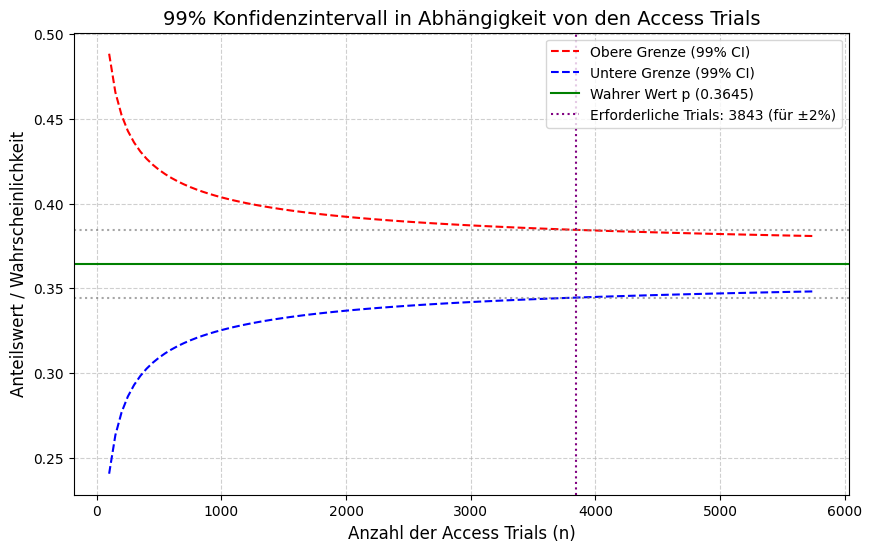

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- 1. Basisdaten aus Exercise 11 ---
p_A = 3 / 500          # Wahrscheinlichkeit autorisiert zu sein
p_not_A = 497 / 500    # Wahrscheinlichkeit nicht autorisiert zu sein
p_G_given_A = 0.95     # Sensitivität
p_G_given_not_A = 0.01 # Falsch-Positiv-Rate

# Satz von Bayes zur Bestimmung der wahren Erfolgswahrscheinlichkeit p
p = (p_G_given_A * p_A) / (p_G_given_A * p_A + p_G_given_not_A * p_not_A)
print(True, f"Wahre Erfolgswahrscheinlichkeit (p): {p:.5f}")

# --- 2. Parameter für Exercise 20 ---
confidence_level = 0.99
accuracy = 0.02  # Maximaler Fehler (Margin of Error)

# Kritischer Z-Wert für 99% Konfidenz (z_alpha/2)
z_val = stats.norm.ppf(1 - (1 - confidence_level) / 2) #percent point function (inverse of cdf) -> gibt z-wert bei 99% CI zurück
print(f"Kritischer Z-Wert für 99% Konfidenz: {z_val:.4f}")

# --- 3. Notwendige Anzahl an Versuchen (n) berechnen ---
# Formel: n = (z^2 * p * (1 - p)) / E^2
n_required = (z_val**2 * p * (1 - p)) / (accuracy**2) 
n_required = int(np.ceil(n_required))
print(f"Notwendige Anzahl an Access Trials für 2% Genauigkeit: {n_required}\n")

# --- 4. Grafische Visualisierung ---
# Wir simulieren eine Spanne von Trials (von 100 bis zum 1.5-fachen des Maximums)
trials_range = np.arange(100, int(n_required * 1.5), 50)

# Berechne die Fehlermarge (Margin of Error) für jeden Trial-Wert
margin_of_errors = z_val * np.sqrt((p * (1 - p)) / trials_range)

# Obere und untere Grenzen des Konfidenzintervalls
lower_bounds = p - margin_of_errors
upper_bounds = p + margin_of_errors

# Plot erstellen
plt.figure(figsize=(10, 6))
plt.plot(trials_range, upper_bounds, 'r--', label='Obere Grenze (99% CI)')
plt.plot(trials_range, lower_bounds, 'b--', label='Untere Grenze (99% CI)')
plt.axhline(y=p, color='g', linestyle='-', label=f'Wahrer Wert p ({p:.4f})')

# Markierung für die geforderte 2% Genauigkeit
plt.axvline(x=n_required, color='purple', linestyle=':', 
            label=f'Erforderliche Trials: {n_required} (für ±2%)')
plt.axhline(y=p + accuracy, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=p - accuracy, color='gray', linestyle=':', alpha=0.7)

# Diagramm-Beschriftungen
plt.title('99% Konfidenzintervall in Abhängigkeit von den Access Trials', fontsize=14)
plt.xlabel('Anzahl der Access Trials (n)', fontsize=12)
plt.ylabel('Anteilswert / Wahrscheinlichkeit', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot anzeigen
plt.show()

In [7]:
# --- Bekannte Werte aus den vorherigen Schritten ---
p = 0.36445          # Wahre Erfolgswahrscheinlichkeit
confidence_level = 0.99
accuracy = 0.02
z_val = stats.norm.ppf(1 - (1 - confidence_level) / 2)

# Berechnete notwendige Trials pro Simulation
n_trials = int(np.ceil((z_val**2 * p * (1 - p)) / (accuracy**2))) # 3847

# --- Bestimmung der Anzahl der Simulationen (M) ---
# Für eine "angemessene Genauigkeit" der Simulation wählt man typischerweise M = 10.000
M_simulations = 10000
print(f"Starte {M_simulations} Simulationen mit jeweils {n_trials} Trials...\n")

# --- Durchführung der Monte-Carlo-Simulation ---
# Wir simulieren für jede der M Simulationen die Anzahl der Erfolge.
# Da es sich um Ja/Nein-Entscheidungen handelt, nutzen wir die Binomialverteilung.
erfolge = np.random.binomial(n=n_trials, p=p, size=M_simulations)

# Berechne den geschätzten Anteil (p_hut) für jede der M Simulationen
p_hat_verlauf = erfolge / n_trials

# Berechne die Fehlermarge für jede Simulation (basierend auf dem geschätzten p_hat)
standard_fehler = np.sqrt((p_hat_verlauf * (1 - p_hat_verlauf)) / n_trials)
fehlermarge = z_val * standard_fehler

# Untere und obere Grenzen für alle M Simulationen berechnen
untere_grenzen = p_hat_verlauf - fehlermarge
obere_grenzen = p_hat_verlauf + fehlermarge

# Prüfen, wie oft der WAHRE WERT p im simulierten Intervall liegt
treffer = (untere_grenzen <= p) & (p <= obere_grenzen)
tatsaechliche_konfidenz = np.mean(treffer)

# --- Ausgabe der Ergebnisse ---
print("--- Simulationsergebnis ---")
print(f"Gewählte Anzahl an Simulationen (M): {M_simulations}")
print(f"In {tatsaechliche_konfidenz * 100:.2f}% aller Simulationen lag der wahre Wert im CI.")
print(f"Erwartet wurden: {confidence_level * 100:.1f}%")

Starte 10000 Simulationen mit jeweils 3843 Trials...

--- Simulationsergebnis ---
Gewählte Anzahl an Simulationen (M): 10000
In 98.99% aller Simulationen lag der wahre Wert im CI.
Erwartet wurden: 99.0%
